# Week 13 Lab Assignment: Social Media Analytics and Trend Analysis

### Objective
In this lab, you will apply advanced text mining techniques to analyze social media data, perform trend analysis, and extract meaningful insights. The lab focuses on using advanced sentiment analysis, keyword trend tracking, and topic modeling to understand social media discussions.

### 1. Setup and Installations
**Objective:** Ensure all necessary packages are installed and imported for the lab.

**Tasks:**
1. Install required Python packages: Scikit-learn, Pandas, Numpy, Matplotlib, Seaborn, NLTK, Gensim, TensorFlow, and Tweepy.

In [36]:
# Install necessary packages
%pip install scikit-learn pandas numpy matplotlib seaborn nltk gensim tensorflow tweepy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### 2. Import Libraries
**Objective:** Import all necessary libraries for data manipulation, text processing, modeling, and visualization.


In [37]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# from gensim import corpora, models
# import tweepy
nltk.download('stopwords')
nltk.download('punkt')
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\w200jrs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\w200jrs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### 3. Social Media Data Collection
**Objective:** Collect data from social media platforms (e.g., Twitter) using APIs.

**Tasks:**
1. **Set up Twitter API Access:** Use Tweepy to collect tweets based on specific keywords or hashtags.
2. **Store Data:** Save the collected tweets into a Pandas DataFrame for further analysis.

In [38]:
%pip install feedparser

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:

import feedparser

# # Example code for Twitter data collection using Tweepy
# # Note: Replace 'your_key' with actual Twitter API credentials
# consumer_key = 'your_consumer_key'
# consumer_secret = 'your_consumer_secret'
# access_token = 'your_access_token'
# access_token_secret = 'your_access_token_secret'

# auth = tweepy.OAuthHandler(consumer_key, consumer_secret)
# auth.set_access_token(access_token, access_token_secret)
# api = tweepy.API(auth)

# # Collect tweets containing a specific hashtag
# tweets = api.search(q='#DataScience', count=100, lang='en')
# tweet_data = [[tweet.text, tweet.created_at] for tweet in tweets]

# # Create a DataFrame
# df = pd.DataFrame(tweet_data, columns=['text', 'timestamp'])
# print(df.head())



# Parse the RSS feed from Google Trends
rss_url = 'https://trends.google.com/trending/rss?geo=US'


feed = feedparser.parse(rss_url)

# Extract trending topics and their publication dates
trends_data = [[entry.title, entry.published] for entry in feed.entries]

# Create a DataFrame
df = pd.DataFrame(trends_data, columns=['title', 'published'])
print(df.head())
# Print data statistics
print(df.describe(include='all'))
print(df.info())

           title                        published
0   jared mccain  Tue, 12 Nov 2024 18:20:00 -0800
1   jayson tatum  Tue, 12 Nov 2024 18:20:00 -0800
2    tyler herro  Tue, 12 Nov 2024 18:20:00 -0800
3  celtics score  Tue, 12 Nov 2024 18:20:00 -0800
4     eric adams  Tue, 12 Nov 2024 18:20:00 -0800
               title                        published
count             10                               10
unique            10                                1
top     jared mccain  Tue, 12 Nov 2024 18:20:00 -0800
freq               1                               10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      10 non-null     object
 1   published  10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
None


### 4. Text Preprocessing
**Objective:** Prepare the social media text data by cleaning and tokenizing it.

**Tasks:**
1. **Tokenization:** Split text into individual words or tokens.
2. **Stop Words Removal:** Use NLTK to remove common stop words from the text.
3. **Text Normalization:** Lowercase text, remove punctuation and URLs.

In [40]:
# Text preprocessing function
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    return ' '.join(tokens)

df['cleaned_text'] = df['title'].apply(preprocess_text)
print(df['cleaned_text'].head())

0     jared mccain
1     jayson tatum
2      tyler herro
3    celtics score
4       eric adams
Name: cleaned_text, dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\w200jrs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\w200jrs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 5. Sentiment Analysis
**Objective:** Perform sentiment analysis on social media text using a pre-trained deep learning model (e.g., LSTM).

**Tasks:**
1. **Prepare Data:** Convert text to sequences and split data into training and testing sets.
2. **Build and Train Model:** Use LSTM for sentiment classification.
3. **Evaluate Model:** Evaluate the model's performance using metrics such as accuracy and confusion matrix.

In [41]:
# Example LSTM model setup for sentiment analysis
# Note: This example assumes preprocessed and labeled data (not fully implemented here)
max_words = 5000
embedding_dim = 50
maxlen = 100

# Prepare data (pseudocode, replace with actual preprocessing)
# X_train, X_test, y_train, y_test = ...

# Build LSTM model
model = Sequential()
model.add(Embedding(max_words, embedding_dim))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model (using dummy data for illustration)
# history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# Evaluate model (using dummy data for illustration)
# accuracy = model.evaluate(X_test, y_test)[1]
# print(f'Model Accuracy: {accuracy}')

### 6. Trend Analysis
**Objective:** Perform trend analysis on keywords and hashtags to identify popular topics and public sentiment over time.

**Tasks:**
1. **Keyword Frequency Analysis:** Count the occurrences of specific keywords over time.
2. **Visualize Trends:** Plot the frequency of keywords/hashtags to visualize trends.

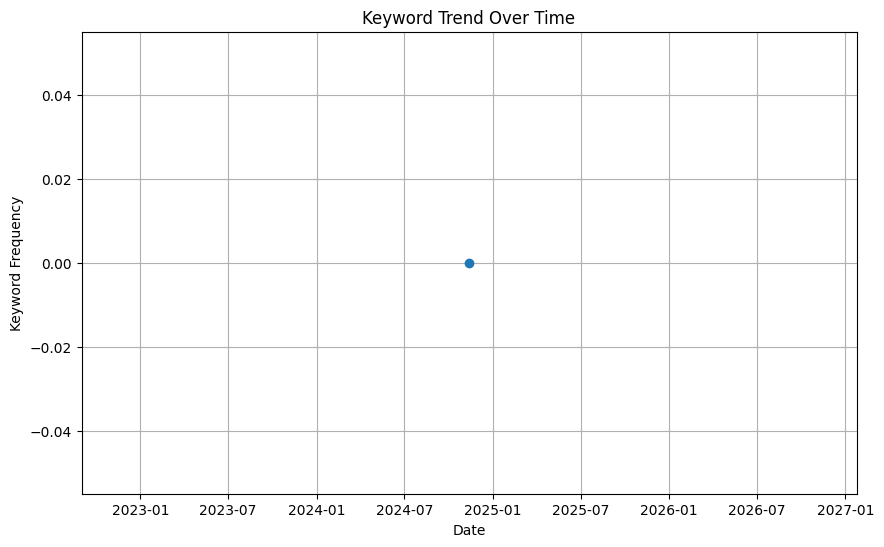

In [42]:
# Ensure 'cleaned_text' column exists
if 'cleaned_text' not in df.columns:
	df['cleaned_text'] = df['title'].apply(preprocess_text)

# Ensure 'published' column exists and is in datetime format
if 'published' in df.columns:
	df['datetime'] = pd.to_datetime(df['published'])
	df.set_index('datetime', inplace=True)
else:
	print("Error: 'published' column not found in DataFrame")

# Count occurrences of a keyword over time
df['keyword_count'] = df['cleaned_text'].str.contains('data').astype(int)
keyword_trend = df['keyword_count'].resample('D').sum()

# Plot the trend
plt.figure(figsize=(10, 6))
plt.plot(keyword_trend, marker='o', linestyle='-')
plt.title('Keyword Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Keyword Frequency')
plt.grid(True)
plt.show()

### 7. Advanced Topic Modeling
**Objective:** Apply advanced topic modeling techniques to analyze social media discussions.

**Tasks:**
1. **Create Dictionary and Corpus:** Use Gensim to create a dictionary and corpus for topic modeling.
2. **Train LDA Model:** Use LDA to find topics within the social media data.
3. **Dynamic Topic Modeling:** Analyze the evolution of topics over time.

In [43]:
# Import necessary gensim modules
%pip install --upgrade numpy gensim

# Ensure 'cleaned_text' column exists
if 'cleaned_text' not in df.columns:
    df['cleaned_text'] = df['title'].apply(preprocess_text)

# Tokenization and stop words removal for LDA
texts = [text.split() for text in df['cleaned_text']]

# Import necessary gensim modules
from gensim import corpora, models

# Create Dictionary and Corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Train LDA Model
lda_model = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Display Topics
topics = lda_model.print_topics(num_words=4)
for topic in topics:
    print(topic)

# Example of Dynamic Topic Modeling (pseudocode, replace with actual implementation)
# dynamic_topics = perform_dynamic_topic_modeling(corpus, dictionary, time_slices)
# for dynamic_topic in dynamic_topics:
#     print(dynamic_topic)

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
Note: you may need to restart the kernel to use updated packages.


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### 8. Summary and Discussion
**Objective:** Reflect on the use of advanced text mining techniques and discuss their implications in the context of social media analytics.

**Tasks:**
1. **Compare Techniques:** Discuss the results from sentiment analysis, trend analysis, and topic modeling.
2. **Business Implications:** Describe how advanced text mining can provide valuable insights for businesses, such as understanding customer feedback and monitoring public opinion.

### 9. Submission
**Deliverables:**
- Jupyter Notebook (.ipynb) with all code, visualizations, and analysis.
- A brief report (1-2 paragraphs) summarizing the findings, including trend analysis results, advanced topic modeling insights, and sentiment analysis outcomes.

**Deadline:** Submit your completed notebook and report to the course portal by the end of class.